# Sun/Moon check

In [1]:
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *
self = KerrModel('../pointlike/from-kerr/toby_v1')

Loaded Kerr model from "../pointlike/from-kerr/toby_v1.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons


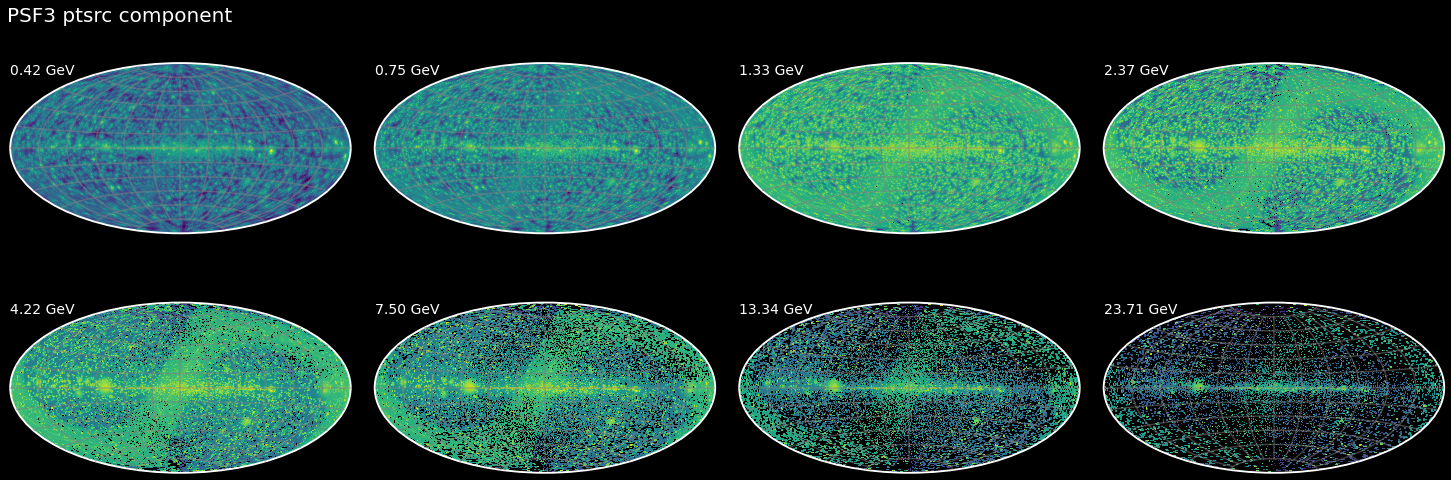

In [2]:
def ptsrc_plots(self, psf=3):
    fig = plt.figure(figsize=(20,7))
    subfigs = fig.subfigures(2, 4, wspace=0.05, hspace=0.)
    for i, subfig in enumerate(subfigs.flat):
        band = self(psf,i+2)
        band.ait_plot('ptsrc',fig=subfig, colorbar=False).title(band.energy, x=0, y=0.9,  ha='left',fontsize=14)
    fig.suptitle(f'PSF{psf} ptsrc component',x=0, ha='left', fontsize=20);
# ptsrc_plots(self, psf=2)
ptsrc_plots(self, psf=3)


Select Band(3, 7): psf3@7.50 GeV nside 512 occ 0.105

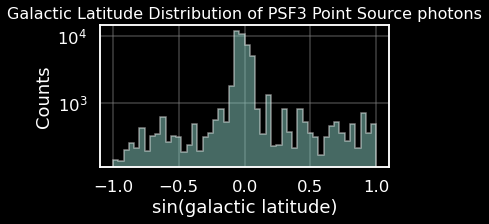

In [3]:
b = self(3,7); show(f'Select {b}')
glat = b.skycoords.b
plt.hist(np.sin(glat.rad), bins=50, weights=b.ptsrc, histtype='stepfilled', alpha=0.5, log=True);
plt.xlabel('sin(galactic latitude)'); plt.ylabel('Counts'); 
plt.title('Galactic Latitude Distribution of PSF3 Point Source photons', fontsize=16);
hilat = np.abs(glat)>Angle(10, 'deg')

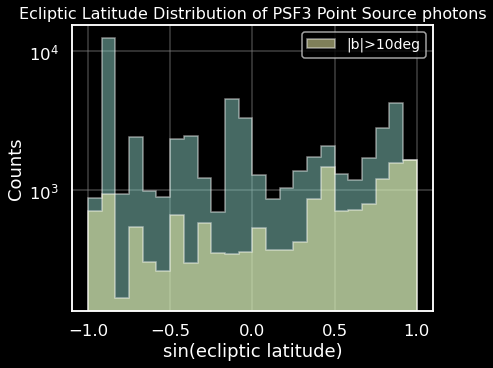

In [4]:
elat = b.skycoords.transform_to('geocentricmeanecliptic').lat.rad
plt.figure(figsize=(6,5))
hkw = dict(bins=24, histtype='stepfilled', alpha=0.5, log=True)
plt.hist(np.sin(elat),  weights=b.ptsrc, **hkw);
plt.hist(np.sin(elat[hilat]),  weights=b.ptsrc[hilat], **hkw, label='|b|>10deg');
plt.legend(fontsize=14);
plt.xlabel('sin(ecliptic latitude)'); plt.ylabel('Counts'); 
plt.title('Ecliptic Latitude Distribution of PSF3 Point Source photons', fontsize=16);

## Ecliptic Distribution of "ptsrc" photons: psf3, 7.50 GeV

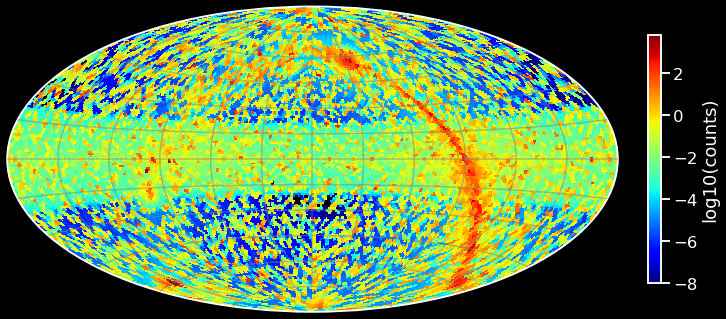

In [11]:
show(f"""## Ecliptic Distribution of "ptsrc" photons: {b.psf}, {b.energy}""")

b.ait_plot('ptsrc', nside=32, frame='geocentricmeanecliptic', cmap='jet', vmin=-8,
           fig=plt.figure(figsize=(10,5)), colorbar=True).title('');
